In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


'''
(1) spatial pathway heatmap
(2) Moran hotspot classification map
'''

df = pd.read_csv("report.csv")


pathways_to_plot = [
    "MACROPHAGE",
    "B_CELL",
    "CD8_MEMORY"
]


moran_colors = {
    0: "lightgray",   # Not significant
    1: "red",         # High-High
    2: "blue",        # Low-Low
    3: "cyan",        # Low-High
    4: "orange"       # High-Low
}


fig, axes = plt.subplots(
    len(pathways_to_plot), 
    2, 
    figsize=(10, 4 * len(pathways_to_plot))
)


for i, pathway in enumerate(pathways_to_plot):


    ax1 = axes[i, 0]

    sc = ax1.scatter(
        df["x"],
        df["y"],
        c=df[pathway],
        cmap="coolwarm",
        s=5
    )

    ax1.set_title(f"{pathway} Activity")
    ax1.invert_yaxis()
    ax1.axis("off")

    plt.colorbar(sc, ax=ax1, fraction=0.046)

    ax2 = axes[i, 1]

    colors = df["quad (sig=0.05)"].map(moran_colors)

    ax2.scatter(
        df["x"],
        df["y"],
        c=colors,
        s=5
    )

    ax2.set_title(f"{pathway} Moran Classification")
    ax2.invert_yaxis()
    ax2.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 1. Identify pathway columns
# ===============================
exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
pathway_cols = [c for c in df.columns if c not in exclude_cols]

# ===============================
# 2. Compute correlation matrix
# ===============================
corr_matrix = df[pathway_cols].corr(method="pearson")

# ===============================
# 3. Plot heatmap with clustering
# ===============================
plt.figure(figsize=(12,10))

sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(12,12)
)

plt.suptitle("Spatial Pathway Correlation Heatmap", y=1.02)
plt.show()


In [ ]:
from libpysal.weights import KNN
from esda.moran import Moran_Local_BV
import matplotlib.pyplot as plt

# ===============================
# 1. Choose two pathways
# ===============================
pathway_A = "MACROPHAGE"
pathway_B = "B_CELL"

# ===============================
# 2. Build spatial neighbors
# ===============================
coords = list(zip(df["x"], df["y"]))
w = KNN.from_array(coords, k=6)
w.transform = "r"

# ===============================
# 3. Compute Bivariate Moran
# ===============================
values_A = df[pathway_A].values
values_B = df[pathway_B].values

moran_bv = Moran_Local_BV(values_A, values_B, w)

df["biv_quad"] = moran_bv.q
df["biv_pval"] = moran_bv.p_sim

# ===============================
# 4. Color mapping
# ===============================
biv_colors = {
    0: "lightgray",
    1: "red",     # High A - High B
    2: "blue",    # Low A - Low B
    3: "cyan",    # Low A - High B
    4: "orange"   # High A - Low B
}

colors = df["biv_quad"].map(biv_colors)

# ===============================
# 5. Plot spatial map
# ===============================
plt.figure(figsize=(6,6))

plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.gca().invert_yaxis()
plt.title(f"Bivariate Moran Map: {pathway_A} vs {pathway_B}")
plt.axis("off")

plt.show()


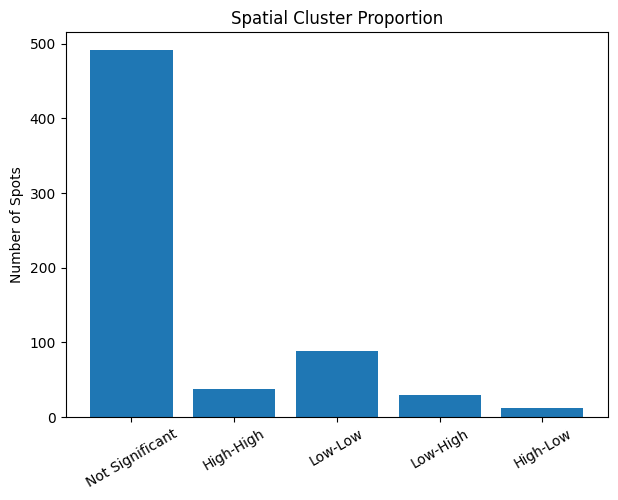

In [9]:
import matplotlib.pyplot as plt

# Cluster Proportion Bar Plot
cluster_counts = df["quad (sig=0.05)"].value_counts().sort_index()

labels_map = {
    0: "Not Significant",
    1: "High-High",
    2: "Low-Low",
    3: "Low-High",
    4: "High-Low"
}

labels = [labels_map[i] for i in cluster_counts.index]

plt.figure(figsize=(7,5))

plt.bar(labels, cluster_counts.values)
plt.ylabel("Number of Spots")
plt.title("Spatial Cluster Proportion")

plt.xticks(rotation=30)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("tissue_image.png")

pathway = "MACROPHAGE"

plt.figure(figsize=(6,6))

plt.imshow(img)


plt.scatter(
    df["x"],
    df["y"],
    c=df[pathway],
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

plt.colorbar(label=pathway)
plt.title(f"{pathway} Overlay on Histology")
plt.axis("off")

plt.show()